### Importing Libraries

In [480]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Importing the Dataset

In [481]:
df=pd.read_csv('data/stud.csv')

### TOP 5 ROWS

In [482]:
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


### Shape of Dataset

In [483]:
df.shape

(1000, 8)

## Checking Missing values

In [484]:
df.isna().sum()

gender                         0
race_ethnicity                 0
parental_level_of_education    0
lunch                          0
test_preparation_course        0
math_score                     0
reading_score                  0
writing_score                  0
dtype: int64

#### There are no missing values

## Check Duplicates

In [485]:
df.duplicated().sum()

np.int64(0)

#### There are no duplicates

In [486]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race_ethnicity               1000 non-null   object
 2   parental_level_of_education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test_preparation_course      1000 non-null   object
 5   math_score                   1000 non-null   int64 
 6   reading_score                1000 non-null   int64 
 7   writing_score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB


## Checking Number of values of each Column

In [487]:
df.nunique()

gender                          2
race_ethnicity                  5
parental_level_of_education     6
lunch                           2
test_preparation_course         2
math_score                     81
reading_score                  72
writing_score                  77
dtype: int64

## Check Statistics of Data

In [488]:
df.describe()

,math_score,reading_score,writing_score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


## Checking Unique Values in each Categorical Columns


In [489]:
df.columns

Index(['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch',
       'test_preparation_course', 'math_score', 'reading_score',
       'writing_score'],
      dtype='object')

In [490]:
print("Values in gender : ",df['gender'].unique())
print("Values in race_ethnicity : ",df['race_ethnicity'].unique())
print("Values in parental_level_of_education : ",df['parental_level_of_education'].unique())
print("Values in lunch : ",df['lunch'].unique())
print("Values in test_preparation_course : ",df['test_preparation_course'].unique())

Values in gender :  ['female' 'male']
Values in race_ethnicity :  ['group B' 'group C' 'group A' 'group D' 'group E']
Values in parental_level_of_education :  ["bachelor's degree" 'some college' "master's degree" "associate's degree"
 'high school' 'some high school']
Values in lunch :  ['standard' 'free/reduced']
Values in test_preparation_course :  ['none' 'completed']


In [491]:
num_features = [feature for feature in df.columns if df[feature].dtype!='O']
cate_features = [feature for feature in df.columns if df[feature].dtype=='O']

print(f"We have {len(num_features)} numerical features : {num_features}")
print(f"\nWe have {len(cate_features)} numerical features : {cate_features}")

We have 3 numerical features : ['math_score', 'reading_score', 'writing_score']

We have 5 numerical features : ['gender', 'race_ethnicity', 'parental_level_of_education', 'lunch', 'test_preparation_course']


## Adding column for total score and average score

In [492]:
df['total_score'] = df['math_score'] + df['reading_score'] + df['writing_score']
df['average'] = df['total_score'] / 3
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [493]:
maths_full = df[df['math_score'] == 100]['average'].count()
reading_full = df[df['reading_score'] == 100]['average'].count()
writing_full = df[df['writing_score']==100]['average'].count()

print(f"Number of students with full marks in maths : {maths_full}")
print(f"Number of students with full marks in reading : {reading_full}")
print(f"Number of students with full marks in writing : {writing_full}")

Number of students with full marks in maths : 7
Number of students with full marks in reading : 17
Number of students with full marks in writing : 14


## VIZUALIZATION

### Histograms

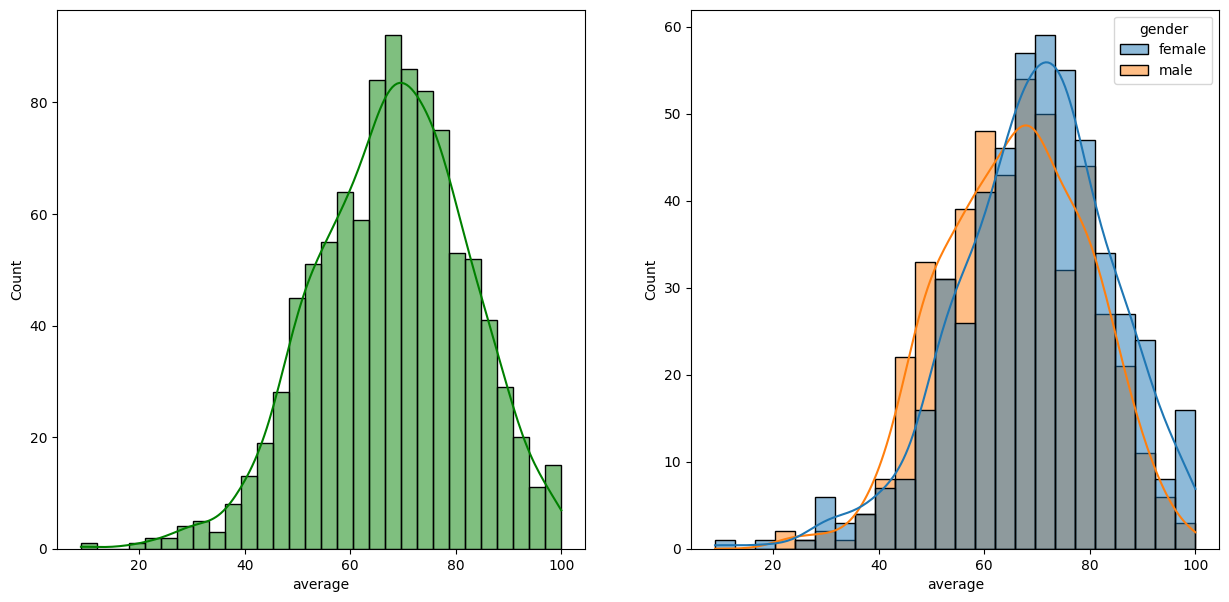

In [494]:
fig,axs = plt.subplots(1,2,figsize=(15,7))

plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,color='g')
plt.subplot(122)
sns.histplot(data=df,x='average',kde=True,hue='gender')
plt.show()

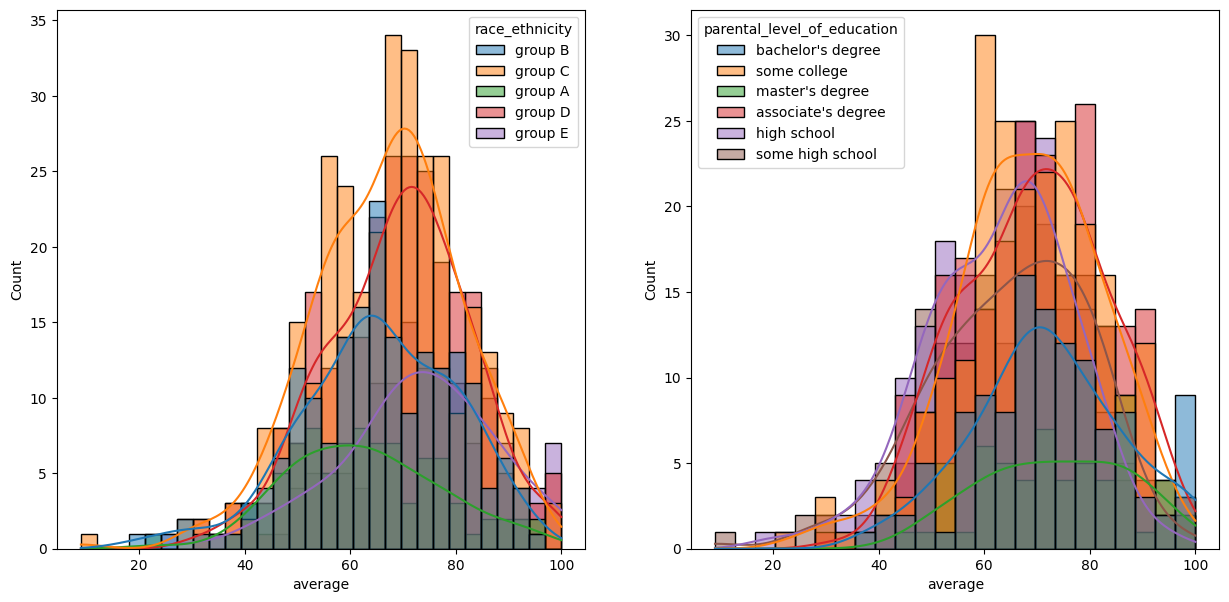

In [495]:
fig,axs = plt.subplots(1,2,figsize=(15,7))

plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,hue='race_ethnicity')
plt.subplot(122)
sns.histplot(data=df,x='average',kde=True,hue='parental_level_of_education')
plt.show()

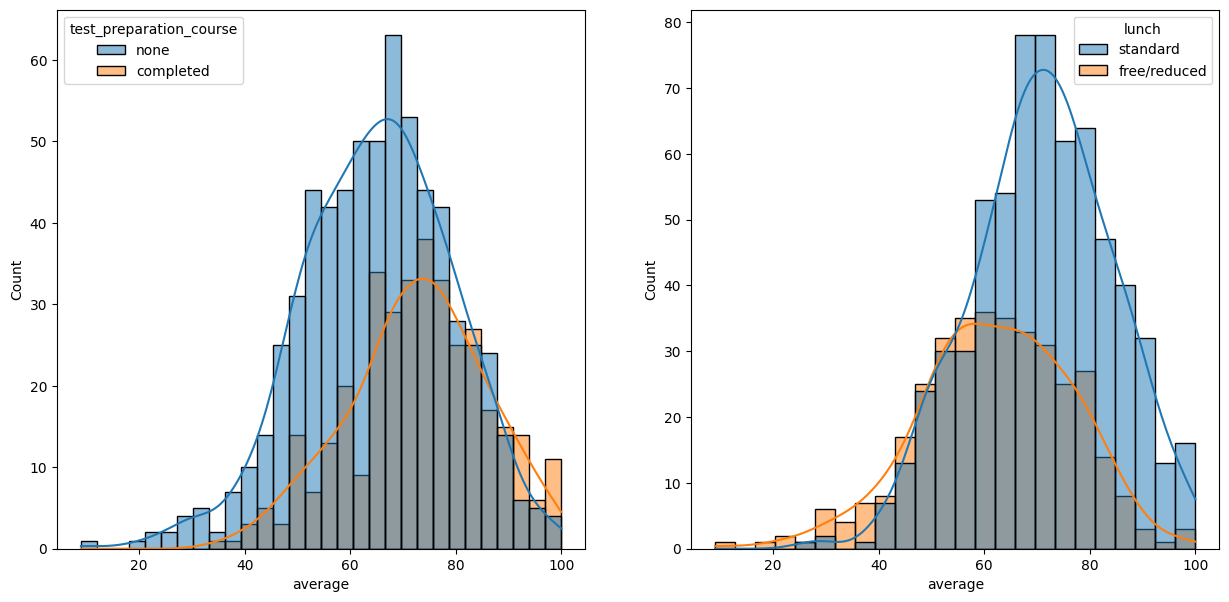

In [496]:
fig,axs = plt.subplots(1,2,figsize=(15,7))

plt.subplot(121)
sns.histplot(data=df,x='average',bins=30,kde=True,hue='test_preparation_course')
plt.subplot(122)
sns.histplot(data=df,x='average',kde=True,hue='lunch')
plt.show()

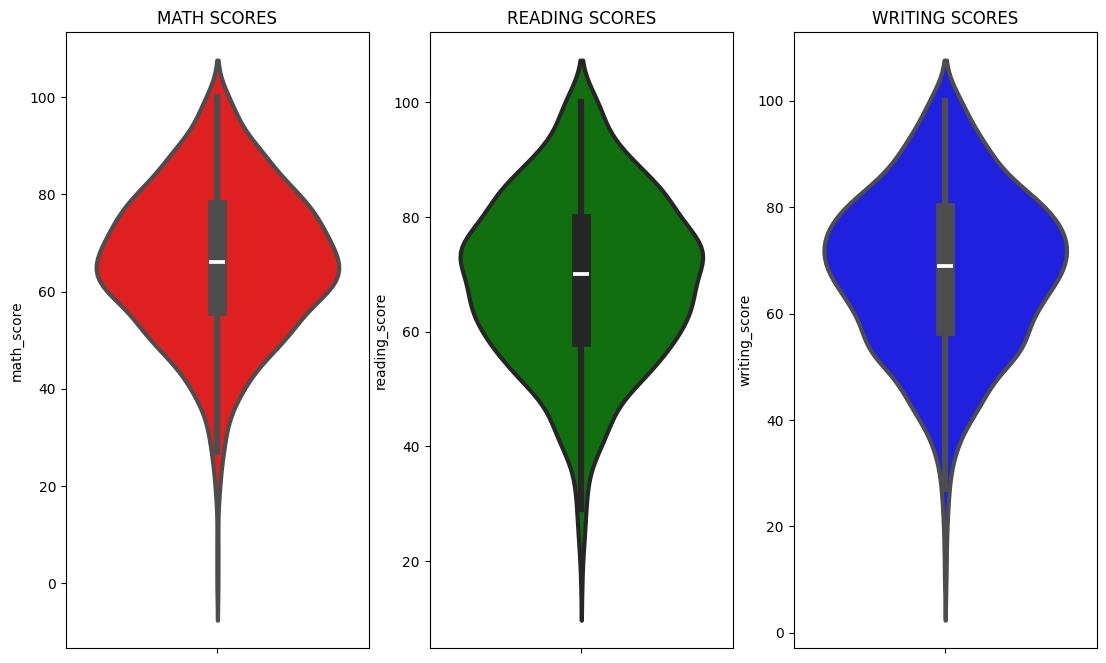

In [497]:
plt.figure(figsize=(18,8))
plt.subplot(1, 4, 1)
plt.title('MATH SCORES')
sns.violinplot(y='math_score',data=df,color='red',linewidth=3)
plt.subplot(1, 4, 2)
plt.title('READING SCORES')
sns.violinplot(y='reading_score',data=df,color='green',linewidth=3)
plt.subplot(1, 4, 3)
plt.title('WRITING SCORES')
sns.violinplot(y='writing_score',data=df,color='blue',linewidth=3)
plt.show()

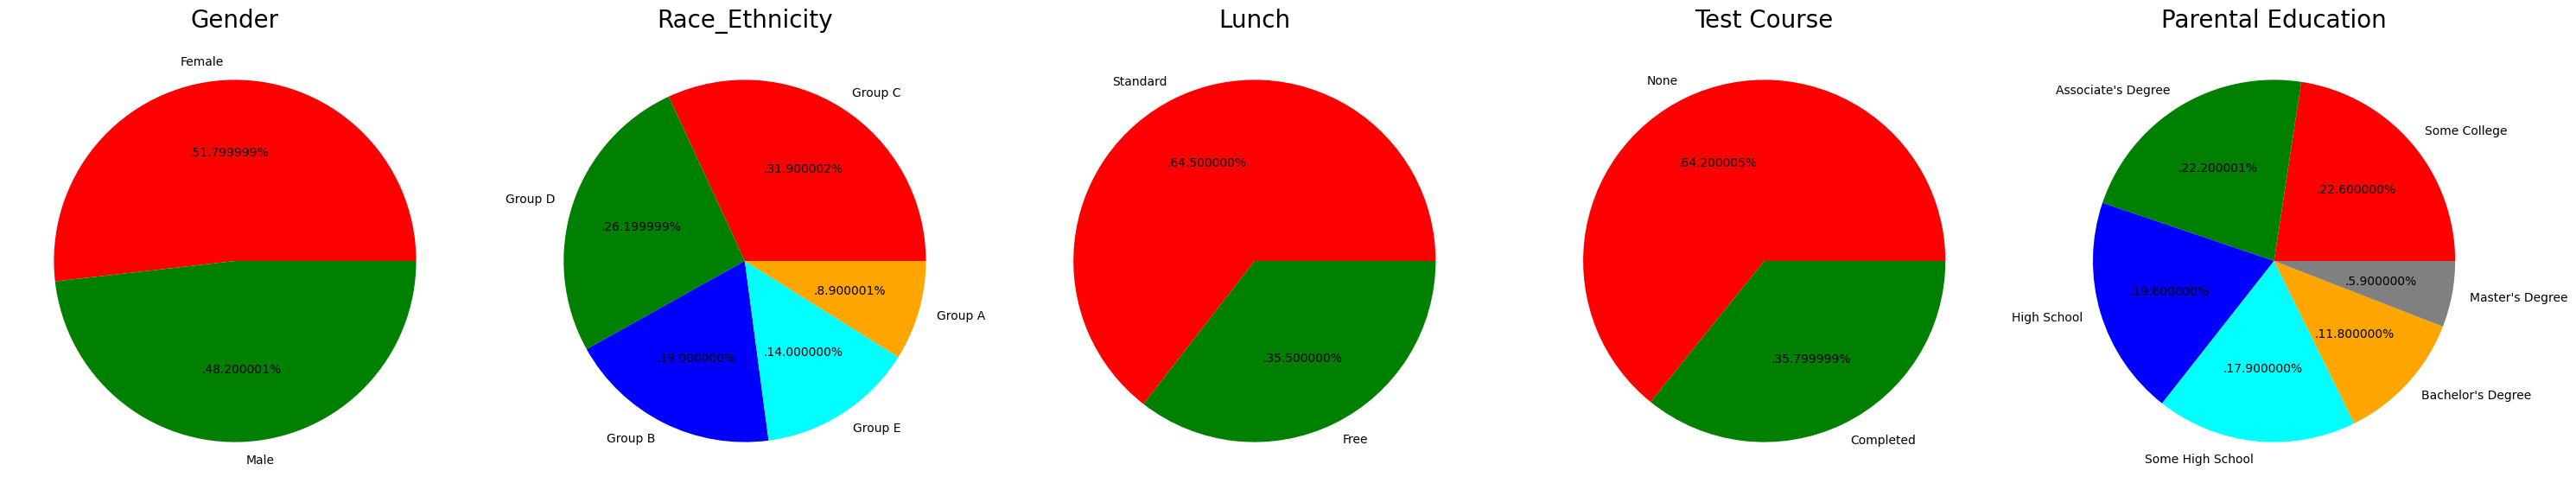

In [498]:
plt.rcParams['figure.figsize'] = (30, 12)

plt.subplot(1, 5, 1)
size = df['gender'].value_counts()
labels = 'Female', 'Male'
color = ['red','green']


plt.pie(size, colors = color, labels = labels,autopct = '.%2f%%')
plt.title('Gender', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 2)
size = df['race_ethnicity'].value_counts()
labels = 'Group C', 'Group D','Group B','Group E','Group A'
color = ['red', 'green', 'blue', 'cyan','orange']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Race_Ethnicity', fontsize = 20)
plt.axis('off')



plt.subplot(1, 5, 3)
size = df['lunch'].value_counts()
labels = 'Standard', 'Free'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Lunch', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 4)
size = df['test_preparation_course'].value_counts()
labels = 'None', 'Completed'
color = ['red','green']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Test Course', fontsize = 20)
plt.axis('off')


plt.subplot(1, 5, 5)
size = df['parental_level_of_education'].value_counts()
labels = 'Some College', "Associate's Degree",'High School','Some High School',"Bachelor's Degree","Master's Degree"
color = ['red', 'green', 'blue', 'cyan','orange','grey']

plt.pie(size, colors = color,labels = labels,autopct = '.%2f%%')
plt.title('Parental Education', fontsize = 20)
plt.axis('off')


plt.tight_layout()
plt.grid()

plt.show()

### Checking Outliers

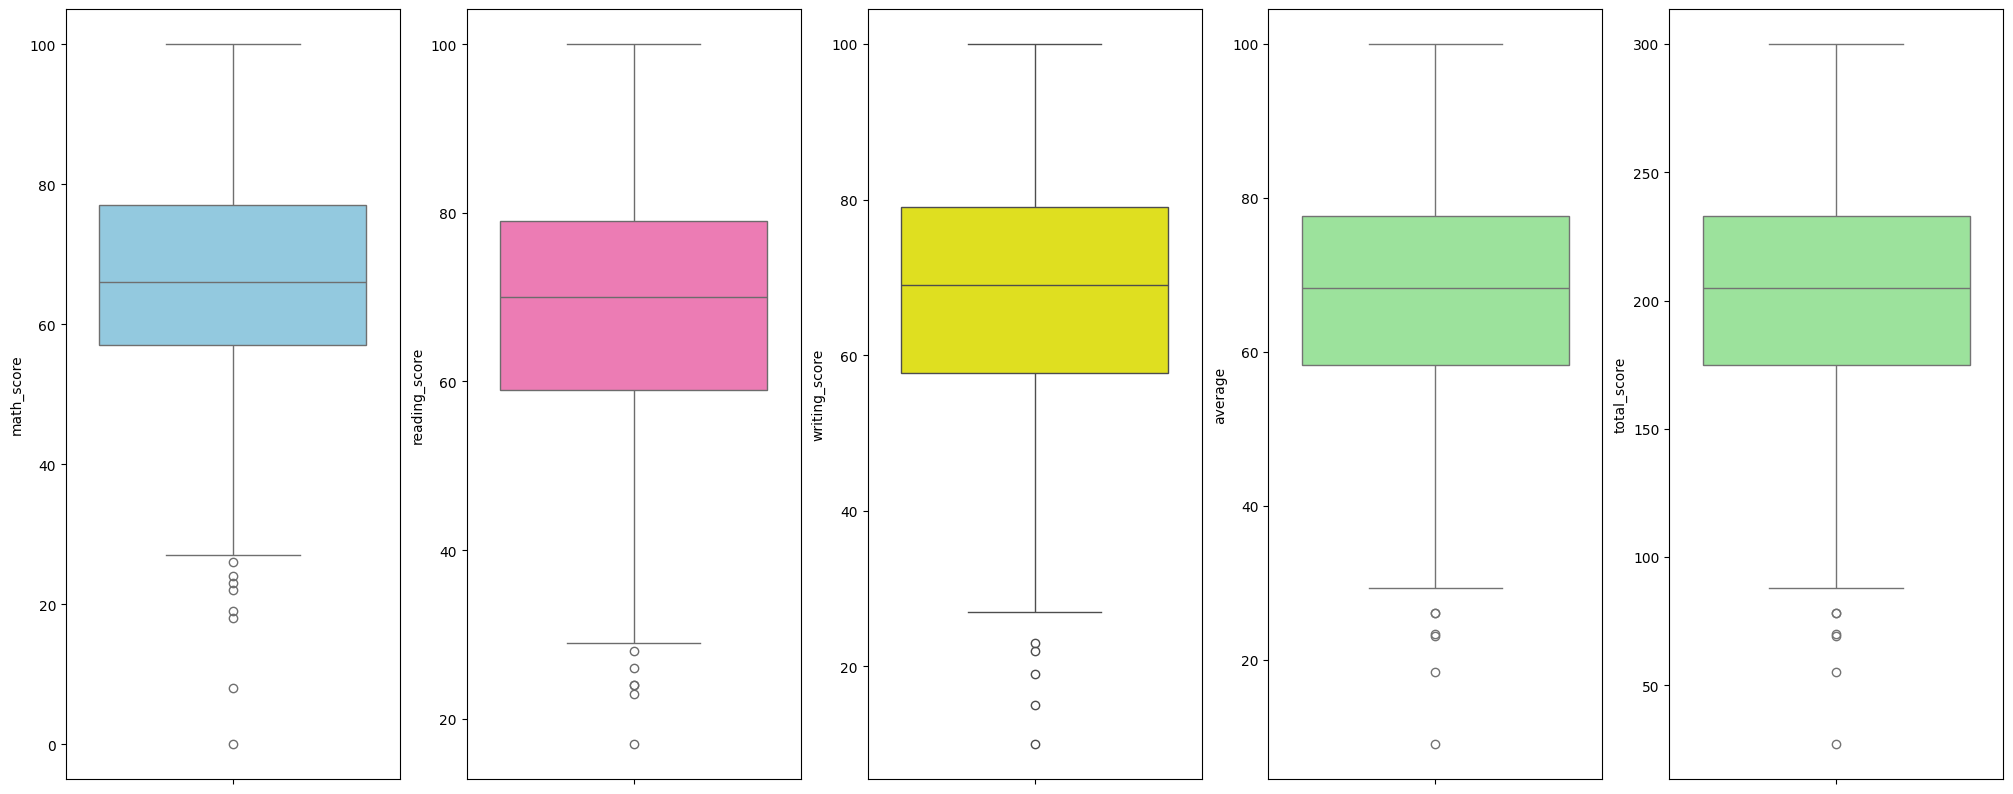

In [499]:
plt.subplots(1,5,figsize=(25,10))
plt.subplot(151)
sns.boxplot(df['math_score'],color='skyblue')
plt.subplot(152)
sns.boxplot(df['reading_score'],color='hotpink')
plt.subplot(153)
sns.boxplot(df['writing_score'],color='yellow')
plt.subplot(154)
sns.boxplot(df['average'],color='lightgreen')
plt.subplot(155)
sns.boxplot(df['total_score'],color='lightgreen')
plt.show()

### Removing Outliers

In [500]:
for col in df.select_dtypes(include=['int64','float64']).columns:
    Q1 = df[col].quantile(0.25)
    Q2 = df[col].median()
    Q3 = df[col].quantile(0.75)

    print(f"\nQ1,Q2 and Q3 for {col} : {Q1,Q2,Q3}")

    IQR = Q3-Q1
    print(f"IQR for {col} : {IQR}")

    lower_fence = Q1-(1.5*IQR)
    higher_fence = Q3+(1.5*IQR)

    df_clean=df[(df[col]>=lower_fence) & (df[col]<=higher_fence) ]


Q1,Q2 and Q3 for math_score : (np.float64(57.0), np.float64(66.0), np.float64(77.0))
IQR for math_score : 20.0

Q1,Q2 and Q3 for reading_score : (np.float64(59.0), np.float64(70.0), np.float64(79.0))
IQR for reading_score : 20.0

Q1,Q2 and Q3 for writing_score : (np.float64(57.75), np.float64(69.0), np.float64(79.0))
IQR for writing_score : 21.25

Q1,Q2 and Q3 for total_score : (np.float64(175.0), np.float64(205.0), np.float64(233.0))
IQR for total_score : 58.0

Q1,Q2 and Q3 for average : (np.float64(58.333333333333336), np.float64(68.33333333333333), np.float64(77.66666666666667))
IQR for average : 19.333333333333336


In [501]:
df_clean.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score,total_score,average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


In [502]:
print(df_clean.shape)
print(df.shape)

(994, 10)
(1000, 10)


In [505]:
df_clean.to_csv('data/cleaned_data.csv',index=False)